In [1]:
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, r"c:\ProjectsDannyDavis\VolatilityPredictionProject\utils")

import API_Keys
from File_Paths import raw_data_filepath
from file_reader import read_file
from returns_utils import append_returns
import plotting_functions as plot_func

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
SAP500 = read_file(raw_data_filepath, r"SP500_price_data.parquet")
SAP500 = SAP500[['simple_return']].dropna()

In [3]:
candidate_models = {
    'Zero':     (0, 0, 0),
    'AR(1)':    (1, 0, 0),
    'AR(2)':    (2, 0, 0),
    'AR(3)':    (3, 0, 0),
    'AR(4)':    (4, 0, 0),
    'AR(5)':    (5, 0, 0),
    'MA(1)':    (0, 0, 1),
    'MA(2)':    (0, 0, 2),
    'MA(3)':    (0, 0, 3),
    'MA(4)':    (0, 0, 4),
    'ARMA(1,1)': (1, 0, 1),
    'ARMA(1,2)': (1, 0, 2),
    'ARMA(2,1)': (2, 0, 1),
    'ARMA(2,2)': (2, 0, 2),
    'ARMA(1,3)': (1, 0, 3),
    'ARMA(3,1)': (3, 0, 1)
}

In [4]:
# Testing for autocorrelation in 'raw' residuals from mean equation

returns_fitted_values = pd.DataFrame()
returns_residuals = pd.DataFrame()
returns_model_result = pd.DataFrame()

for candidate, order in candidate_models.items():
    model = ARIMA(SAP500, order=order).fit()
    returns_fitted_values[candidate] = model.fittedvalues
    returns_residuals[candidate] = model.resid
    result = acorr_ljungbox(model.resid, 
               lags=[20],
               model_df=model.df_model).round(2)
    result['model'] = candidate
    returns_model_result = pd.concat([returns_model_result, result])

c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  se

In [5]:
# Result: reject H0 that there is no autocorrelation in residuals across all models

returns_model_result

,lb_stat,lb_pvalue,model
20,248.29,0.0,Zero
20,144.74,0.0,AR(1)
20,119.29,0.0,AR(2)
20,112.83,0.0,AR(3)
20,95.83,0.0,AR(4)
20,96.06,0.0,AR(5)
20,155.79,0.0,MA(1)
20,124.75,0.0,MA(2)
20,109.21,0.0,MA(3)
20,106.60,0.0,MA(4)


In [6]:
# squared residuals

returns_fitted_values = pd.DataFrame()
var_residuals = pd.DataFrame()
var_model_result = pd.DataFrame()

for candidate, order in candidate_models.items():
    model = ARIMA(SAP500, order=order).fit()
    returns_fitted_values[candidate] = model.fittedvalues
    var_residuals[candidate] = model.resid ** 2
    result = acorr_ljungbox(model.resid **2, 
               lags=[20],
               model_df=model.df_model).round(2)
    result['model'] = candidate
    var_model_result = pd.concat([var_model_result, result])

c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  se

In [ ]:
# Result: reject H0 that there is no autocorrelation in residuals across all models

    # likely due to extremely large sample size

var_model_result

,lb_stat,lb_pvalue,model
20,4948.19,0.0,Zero
20,4479.51,0.0,AR(1)
20,4160.07,0.0,AR(2)
20,4108.42,0.0,AR(3)
20,4216.23,0.0,AR(4)
20,4209.35,0.0,AR(5)
20,4578.32,0.0,MA(1)
20,4225.91,0.0,MA(2)
20,4163.69,0.0,MA(3)
20,4340.48,0.0,MA(4)


#### VISUALS

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.graphics.tsaplots import plot_acf

# Build combined LB DataFrame for Panel D grouped bar chart
lb_returns  = returns_model_result.set_index('model')[['lb_stat']].rename(columns={'lb_stat': 'LB on Residuals'})
lb_squared  = var_model_result.set_index('model')[['lb_stat']].rename(columns={'lb_stat': 'LB on Sq. Residuals'})
lb_combined = lb_returns.join(lb_squared).reset_index()   # (16 × 3): model | LB on Residuals | LB on Sq. Residuals

lb_combined

,model,LB on Residuals,LB on Sq. Residuals
0,Zero,248.29,4948.19
1,AR(1),144.74,4479.51
2,AR(2),119.29,4160.07
3,AR(3),112.83,4108.42
4,AR(4),95.83,4216.23
5,AR(5),96.06,4209.35
6,MA(1),155.79,4578.32
7,MA(2),124.75,4225.91
8,MA(3),109.21,4163.69
9,MA(4),106.60,4340.48


c:\ProjectsDannyDavis\VolatilityPredictionProject\utils\plotting_functions.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\ProjectsDannyDavis\VolatilityPredictionProject\utils\plotting_functions.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\ProjectsDannyDavis\VolatilityPredictionProject\utils\plotting_functions.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\ProjectsDannyDavis\VolatilityPredictionProject\utils\plotting_functions.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


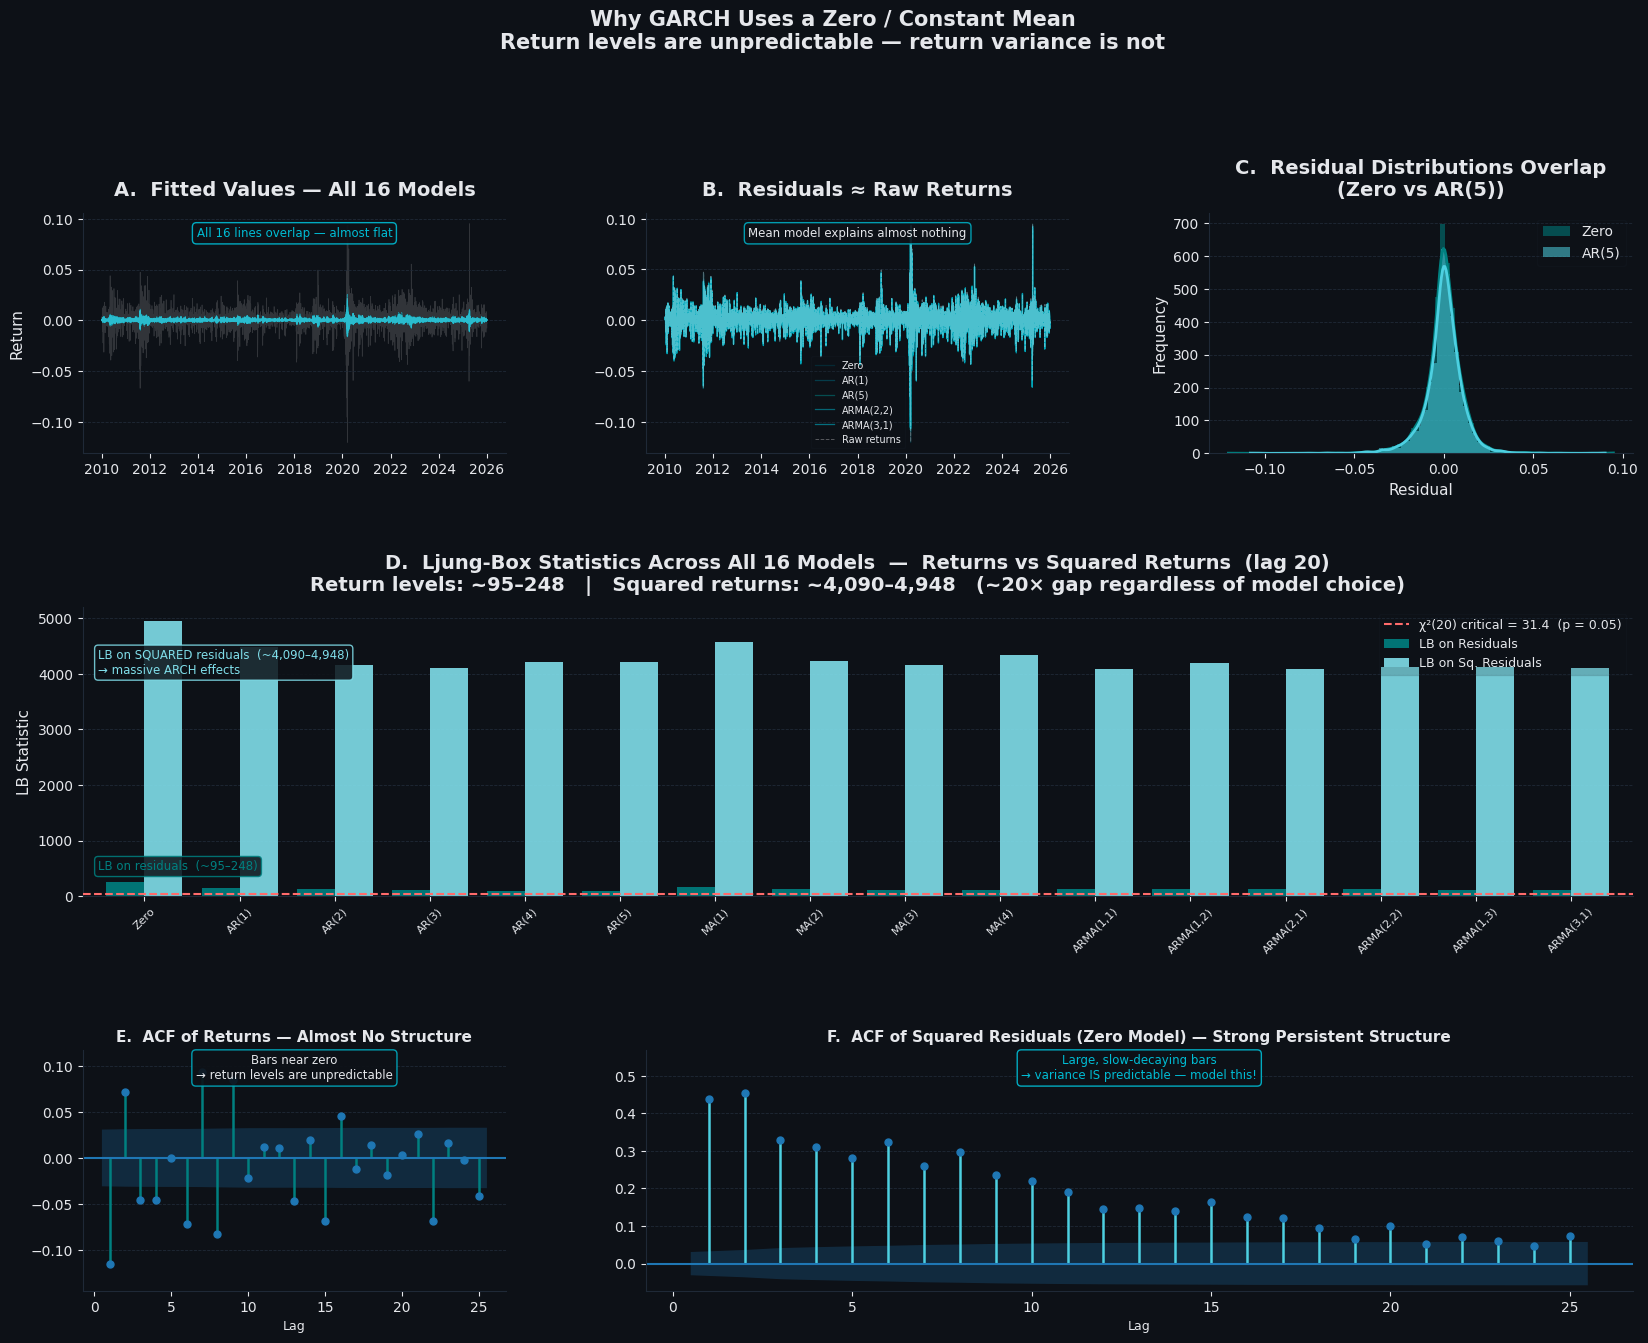

In [11]:
# ── CELL B: 6-panel visualization — Why GARCH uses a zero/constant mean ───────
DARK   = True
TEAL   = plot_func.TEAL_SEQUENCE
BG     = "#0D1117"
TEXT   = "#E5E7EB"
ACCENT = "#00BCD4"
HIGHLIGHT_MODELS = ['Zero', 'AR(1)', 'AR(5)', 'ARMA(2,2)', 'ARMA(3,1)']

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(BG)

gs = gridspec.GridSpec(
    nrows=3, ncols=3, figure=fig,
    height_ratios=[1, 1.2, 1],
    hspace=0.60, wspace=0.33,
)
ax_A = fig.add_subplot(gs[0, 0])   # spaghetti fitted values
ax_B = fig.add_subplot(gs[0, 1])   # residuals vs raw returns
ax_C = fig.add_subplot(gs[0, 2])   # overlapping histograms
ax_D = fig.add_subplot(gs[1, :])   # LB grouped bar — full width (money panel)
ax_E = fig.add_subplot(gs[2, 0])   # ACF of returns
ax_F = fig.add_subplot(gs[2, 1:])  # ACF of squared residuals (wider)

# ── Panel A: All 16 fitted value series (spaghetti) ──────────────────────────
plot_func.plot_line(
    data=returns_fitted_values,
    title="A.  Fitted Values — All 16 Models",
    xlabel="", ylabel="Return",
    colors=TEAL, linewidth=0.8, alpha=0.4, dark=DARK, ax=ax_A,
)
ax_A.plot(SAP500.index, SAP500['simple_return'].values,
          color='white', linewidth=0.5, alpha=0.15, zorder=0)
leg = ax_A.get_legend()
if leg:
    leg.remove()
ax_A.text(0.5, 0.90, "All 16 lines overlap — almost flat",
          transform=ax_A.transAxes, ha='center', fontsize=8.5, color=ACCENT,
          bbox=dict(boxstyle='round,pad=0.35', facecolor=BG, alpha=0.9, edgecolor=ACCENT))

# ── Panel B: Residuals vs raw returns (5 selected models) ────────────────────
plot_func.plot_line(
    data=returns_residuals[HIGHLIGHT_MODELS],
    title="B.  Residuals ≈ Raw Returns",
    xlabel="", ylabel="",
    colors=TEAL[:5], linewidth=0.9, alpha=0.55, dark=DARK, ax=ax_B,
)
ax_B.plot(SAP500.index, SAP500['simple_return'].values,
          color='white', linewidth=0.7, alpha=0.30, linestyle='--', label='Raw returns')
ax_B.legend(fontsize=7, framealpha=0.15, edgecolor='#1F2937',
            labelcolor=TEXT, facecolor=BG)
ax_B.text(0.5, 0.90, "Mean model explains almost nothing",
          transform=ax_B.transAxes, ha='center', fontsize=8.5, color=TEXT,
          bbox=dict(boxstyle='round,pad=0.35', facecolor=BG, alpha=0.9, edgecolor=TEAL[3]))

# ── Panel C: Residual distribution overlay (Zero vs AR(5)) ───────────────────
plot_func.plot_histogram(
    data={'Zero': returns_residuals['Zero'], 'AR(5)': returns_residuals['AR(5)']},
    bins=80, title="C.  Residual Distributions Overlap\n(Zero vs AR(5))",
    xlabel="Residual", ylabel="Frequency",
    colors=[TEAL[2], TEAL[6]], alpha=0.55, kde=True, dark=DARK, ax=ax_C,
)

# ── Panel D: Grouped bar chart (the money panel) ─────────────────────────────
plot_func.plot_bar(
    data=lb_combined,
    x='model', y=['LB on Residuals', 'LB on Sq. Residuals'],
    title="D.  Ljung-Box Statistics Across All 16 Models  —  Returns vs Squared Returns  (lag 20)\n"
          "Return levels: ~95–248   |   Squared returns: ~4,090–4,948   (~20× gap regardless of model choice)",
    xlabel="", ylabel="LB Statistic",
    colors=[TEAL[2], TEAL[7]], dark=DARK, ax=ax_D,
)
ax_D.tick_params(axis='x', rotation=45, labelsize=8)
ax_D.axhline(31.4, color='#FF6B6B', linewidth=1.5, linestyle='--',
             zorder=5, label='χ²(20) critical = 31.4  (p = 0.05)')
ax_D.text(0.01, 0.08, "LB on residuals  (~95–248)",
          transform=ax_D.transAxes, fontsize=8.5, color=TEAL[2], va='bottom',
          bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, edgecolor=TEAL[2], alpha=0.85))
ax_D.text(0.01, 0.76, "LB on SQUARED residuals  (~4,090–4,948)\n→ massive ARCH effects",
          transform=ax_D.transAxes, fontsize=8.5, color=TEAL[7], va='bottom',
          bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, edgecolor=TEAL[7], alpha=0.85))
ax_D.legend(fontsize=9, framealpha=0.15, edgecolor='#1F2937',
            labelcolor=TEXT, facecolor=BG)

# ── Panel E: ACF of raw returns (near-zero bars) ─────────────────────────────
plot_acf(SAP500['simple_return'].dropna(), lags=25, ax=ax_E, zero=False,
         title="E.  ACF of Returns — Almost No Structure",
         auto_ylims=True, vlines_kwargs={'colors': TEAL[2], 'linewidth': 1.8})
plot_func._apply_dark_theme(ax_E, fig)
ax_E.title.set_color(TEXT)
ax_E.title.set_fontsize(11)
ax_E.title.set_fontweight('bold')
ax_E.set_xlabel("Lag", fontsize=9, color=TEXT)
ax_E.text(0.5, 0.88, "Bars near zero\n→ return levels are unpredictable",
          transform=ax_E.transAxes, ha='center', fontsize=8.5, color=TEXT,
          bbox=dict(boxstyle='round,pad=0.35', facecolor=BG, edgecolor=TEAL[3], alpha=0.9))

# ── Panel F: ACF of squared residuals (large, persistent bars) ───────────────
plot_acf(returns_residuals['Zero'].dropna() ** 2, lags=25, ax=ax_F, zero=False,
         title="F.  ACF of Squared Residuals (Zero Model) — Strong Persistent Structure",
         auto_ylims=True, vlines_kwargs={'colors': TEAL[6], 'linewidth': 1.8})
plot_func._apply_dark_theme(ax_F, fig)
ax_F.title.set_color(TEXT)
ax_F.title.set_fontsize(11)
ax_F.title.set_fontweight('bold')
ax_F.set_xlabel("Lag", fontsize=9, color=TEXT)
ax_F.text(0.5, 0.88, "Large, slow-decaying bars\n→ variance IS predictable — model this!",
          transform=ax_F.transAxes, ha='center', fontsize=8.5, color=ACCENT,
          bbox=dict(boxstyle='round,pad=0.35', facecolor=BG, edgecolor=ACCENT, alpha=0.9))

# ── Suptitle ──────────────────────────────────────────────────────────────────
fig.suptitle(
    "Why GARCH Uses a Zero / Constant Mean\n"
    "Return levels are unpredictable — return variance is not",
    fontsize=15, fontweight='bold', color=TEXT, y=1.025,
)

plt.savefig('mean_equation_viz.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()